## Importing the needed libraries for the dataset
- We first get the neccesary libraries to deal with the iris dataset.


In [1]:
# importing neccesary libraries
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Loading the dataset and display
- We now load the dataset
- Display the first 5 rows

In [2]:
# loading the iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# adding the target variable to the dataframe
df['flower'] = iris.target
# displaying the first 5 rows of the dataframe
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   flower  
0       0  
1       0  
2       0  
3       0  
4       0  


In [3]:

df['flower'] = df['flower'].apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Exploring the dataset
- We check the number of rows and columns and review the features such as:
- sepal length
- sepal width
- petal length
- petal width

In [4]:
# checking number of rows and columns in the dataframe
print("Shape of dataset:", df.shape)
print("Column names:", df.columns.tolist())

# reviewing the summary statistics of the dataset
print(df.describe())
print(df.info())
# checking for missing values in the dataset
print("Missing values in each column:\n", df.isnull().sum())

Shape of dataset: (150, 5)
Column names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'flower']
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  
<class 'pandas.DataFrame'>
RangeIndex: 150 ent

## Applying K-Means clustering
- We apply the K means clustering on the dataset

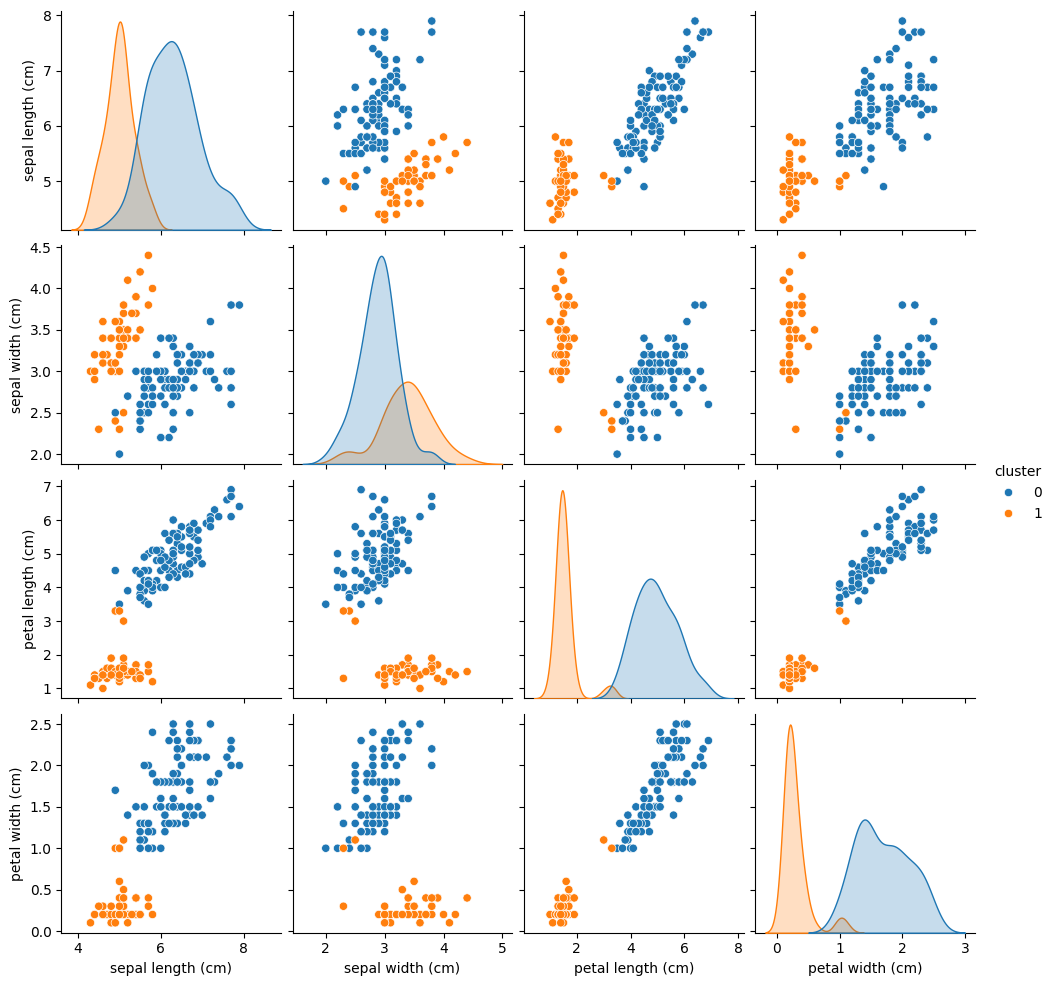

Cluster labels: [1 0]


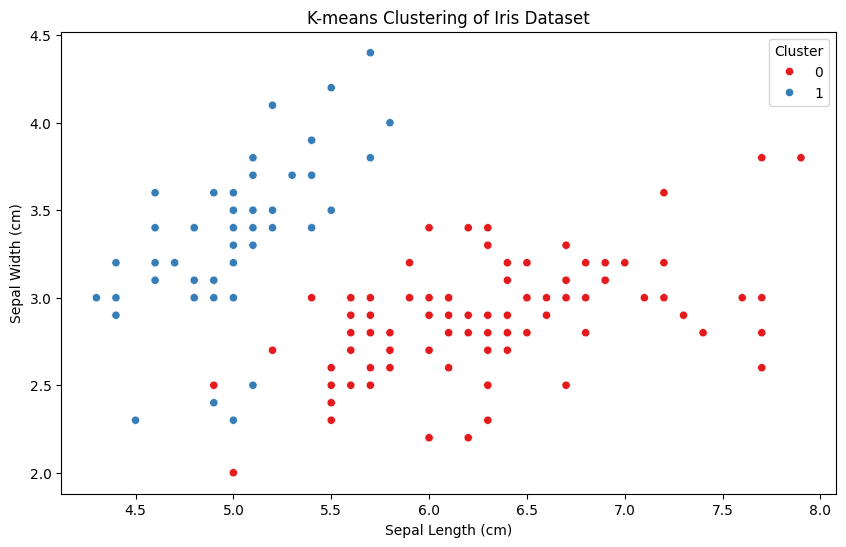

Cluster labels: [1 0]


In [5]:
# K-means clustering
# selecting the features for clustering
X = df[iris.feature_names]
# initializing KMeans with 2 clusters (since there are 2 species of iris)   
kmeans = KMeans(n_clusters=2, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X)
# adding the cluster labels to the original dataframe
df['cluster'] = kmeans.labels_
# visualizing the clusters using a pairplot
sns.pairplot(df, hue='cluster', vars=iris.feature_names)
plt.show()
print("Cluster labels:", df['KMeans_Cluster'].unique())
# plotting clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['sepal length (cm)'], y=df['sepal width (cm)'], hue=df['cluster'], palette='Set1')
plt.title('K-means Clustering of Iris Dataset')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Cluster')
plt.show()
print("Cluster labels:", df['KMeans_Cluster'].unique())

## Determining optimal number of clusters
- To achieve this we use the elbow method

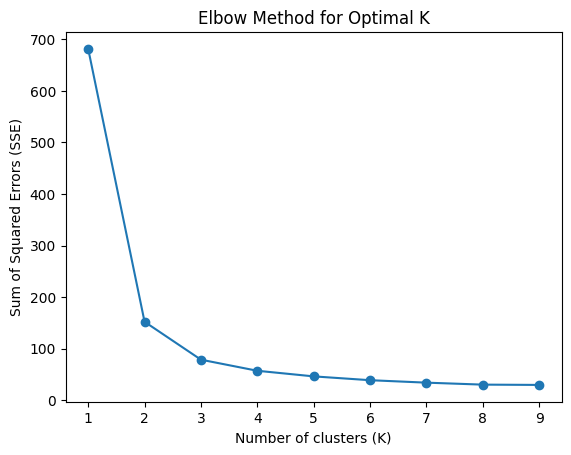

In [6]:
#determine the optimal number of clusters (K) using the elbow method:
k_range = range(1, 10)
sse = []
for k in k_range:
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(X)
  sse.append(km.inertia_)
  
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.show()


## Applying Hierarchical clustering
- We try another method of clustering called  Hierarchical clustering

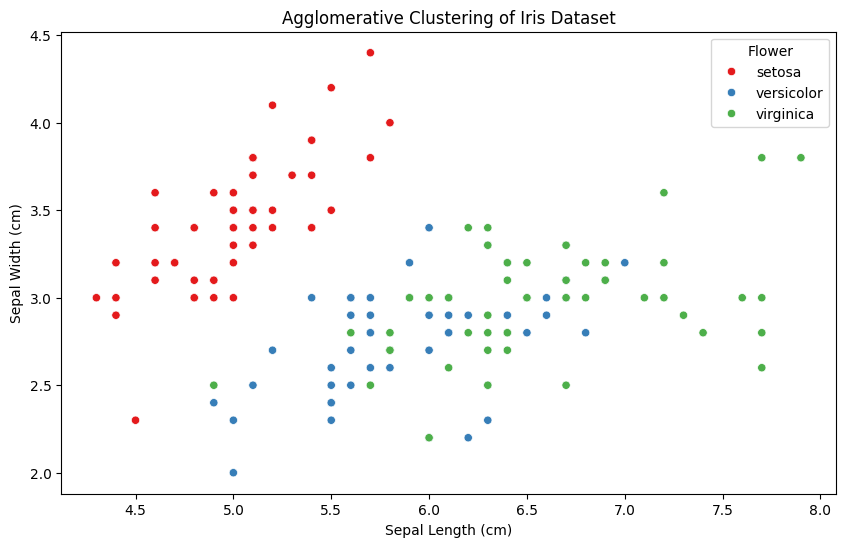

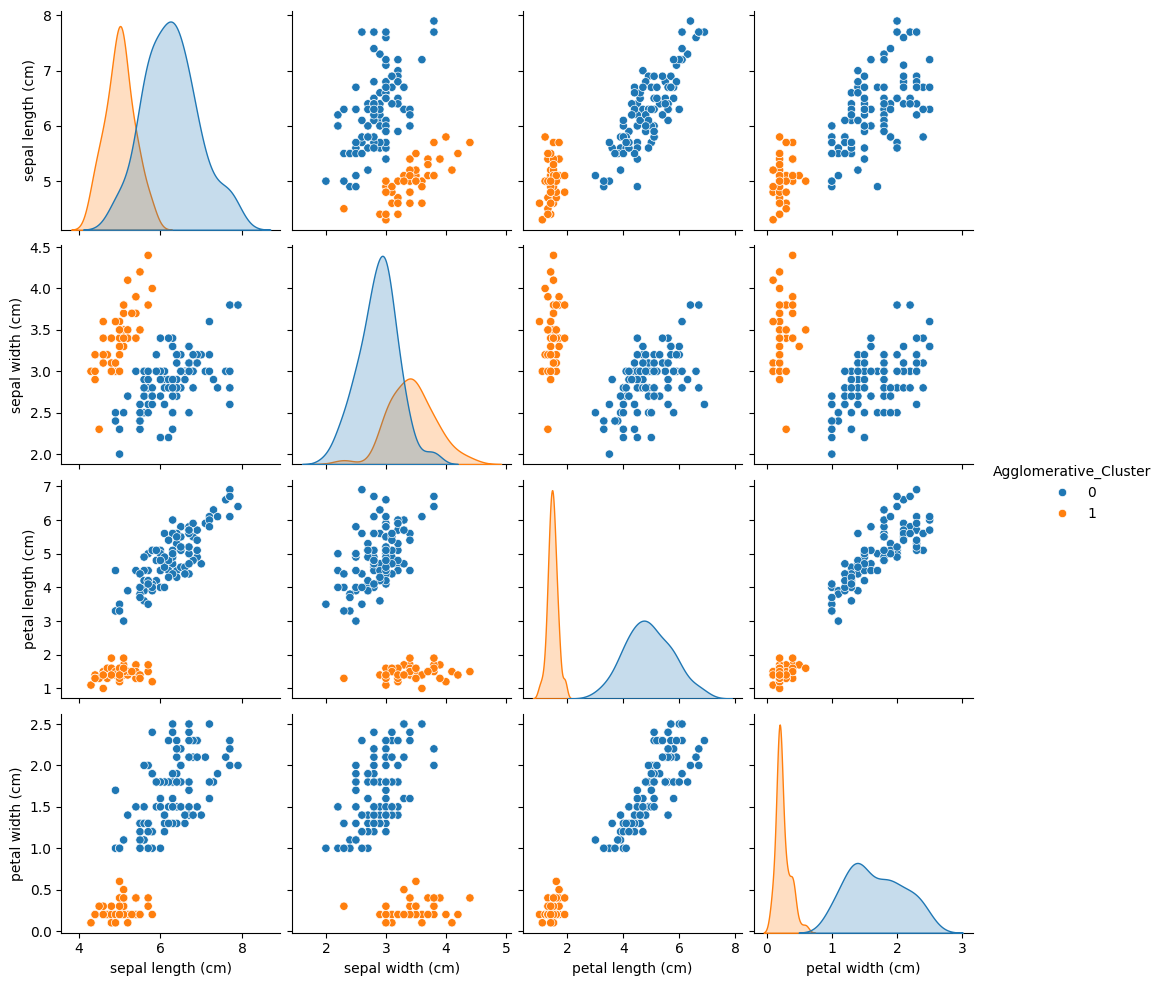

Cluster labels: [1 0]


In [9]:
# Hierarchical clustering

# initializing AgglomerativeClustering with 2 clusters
agg_clustering = AgglomerativeClustering(n_clusters=2) 
# visualizing using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['sepal length (cm)'], y=df['sepal width (cm)'], hue=df['flower'], palette='Set1')
plt.title('Agglomerative Clustering of Iris Dataset')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Flower')
plt.show()
# fitting the model to the data
df['Agglomerative_Cluster'] = agg_clustering.fit_predict(df[iris.feature_names])
# visualizing the clusters using a pairplot
sns.pairplot(df, hue='Agglomerative_Cluster', vars=iris.feature_names)
plt.show()
print("Cluster labels:", df['Agglomerative_Cluster'].unique())

## Plotting a dendogram
- We come up with a dendogram showing how clusters were merged step by step

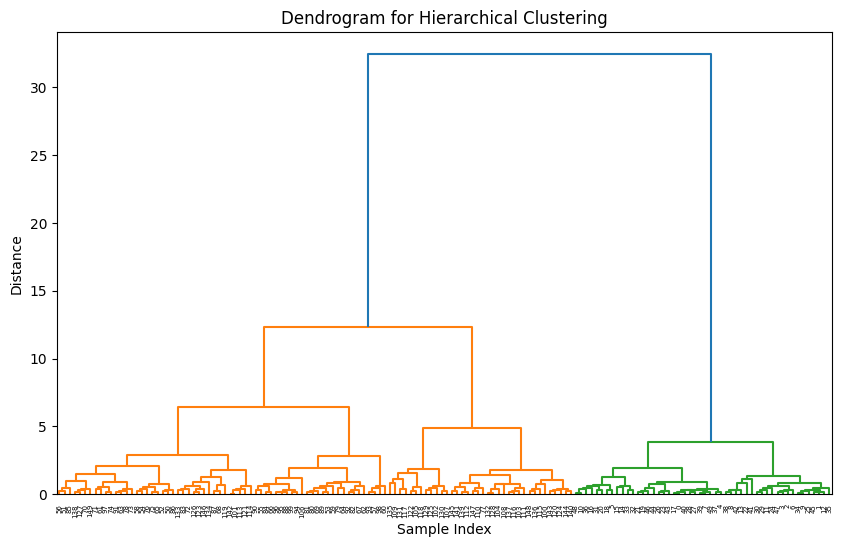

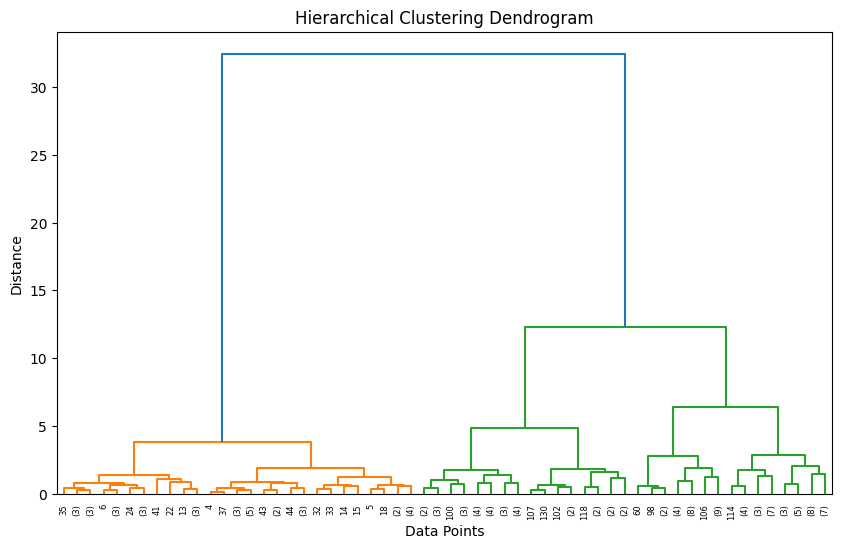

In [ ]:
# Dendrogram for hierarchical clustering
# creating the linkage matrix
linked = linkage(df[iris.feature_names], method='ward')
# plotting the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, labels=df.index, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()
# creating the linkage matrix for truncated dendrogram
linked = linkage(df[iris.feature_names], method='ward')
# plotting the truncated dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

## Evaluation of the clusters
- We calculate the Silhouette Score for both K-Means and Hierarchical clustering.
- We compare the results to determine which method gave better separation between clusters.

In [10]:
# Evaluating clustering performance using silhouette score
# calculating silhouette score for K-means clustering
kmeans_silhouette = silhouette_score(X, df['KMeans_Cluster'])
print("Silhouette Score for K-means Clustering:", kmeans_silhouette)
# calculating silhouette score for Agglomerative Clustering
agg_silhouette = silhouette_score(X, df['Agglomerative_Cluster'])   
print("Silhouette Score for Agglomerative Clustering:", agg_silhouette)

Silhouette Score for K-means Clustering: 0.6810461692117465
Silhouette Score for Agglomerative Clustering: 0.6867350732769781
